In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay 
from sklearn.ensemble import RandomForestClassifier

In [2]:
def wrangle(filepath):
    #read csv into DataFrame
    df = pd.read_csv(filepath)

    # =====================================================
    
    # Merge Patient Admission Date and Patient Admission Time column
    df["Admission DateTime"] = pd.to_datetime(
        df["Patient Admission Date"] + " " + df["Patient Admission Time"], dayfirst=True
    )

    # Drop columns with more than 40% null values, merged, and irrelvant 
    df.drop(columns=(["Department Referral",
                      "Patient Satisfaction Score", 
                      "Patient Admission Date",
                      "Patient Admission Time", 
                      "Patient Id", 
                      "Merged"]),
            inplace=True)

    # =====================================================
    
    # Set Admission DateTime column as index
    df.set_index("Admission DateTime", inplace=True)

    # Sort index
    df.sort_index(inplace=True)

    # Create column with day name
    df.insert(0, "Admission Day", df.index.day_name() )

    # Create Ordered Days in Visualization
    day_order = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]

    df["Admission Day"] = pd.Categorical(
        df["Admission Day"],
        categories = day_order,
        ordered = True
    )


     # Create column with month name
    df.insert(0, "Admission Month", df.index.month_name() )

    # Create Ordered Days in Visualization
    month_order = [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December"
    ]

    df["Admission Month"] = pd.Categorical(
        df["Admission Month"],
        categories = month_order,
        ordered = True
    )

    # Extract hour from datetime index
    df.insert(0, "Time Group", df.index.hour )

    bins = [0, 6, 9, 12, 15, 18, 21, 24]

    labels = [
        "00:00–05:59",
        "06:00–08:59",
        "09:00–11:59",
        "12:00–14:59",
        "15:00–17:59",
        "18:00–20:59",
        "21:00–23:59"
    ]
    
    df["Time Group"] = pd.cut(
        df["Time Group"],
        bins=bins,
        labels=labels,
        right=False,
        include_lowest=True
    )

    # make it chronological
    df["Time Group"] = pd.Categorical(
    df["Time Group"],
    categories=labels,
    ordered=True
    )
    # =====================================================
    
    # Create Age Groups
    bins = [0, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80]

    labels = [
        "Under Five",
        "School Age Child",
        "Early Adolescent",
        "Late Adolescent",
        "Young Adult",
        "Early Adult",
        "Midlife Adult",
        "Late Adult",
        "Young Elderly",
        "Older Elderly"
    ]

    df["Age Group"] = pd.cut(
        df["Patient Age"],
        bins=bins,
        labels=labels,
        right=False
    )

    # Make Age Group Chronological
    df["Age Group"] = pd.Categorical(
        df["Age Group"],
        categories=labels,
        ordered=True
    )

    # Higher-level category mapping
    age_category_map = {
        "Under Five": "Child",
        "School Age Child": "Child",

        "Early Adolescent": "Adolescent",
        "Late Adolescent": "Adolescent",

        "Young Adult": "Adult",
        "Early Adult": "Adult",
        "Midlife Adult": "Adult",
        "Late Adult": "Adult",

        "Young Elderly": "Elderly",
        "Older Elderly": "Elderly"
    }

    df["Age Category"] = df["Age Group"].map(age_category_map)

    # Make the Age Category ordered
    category_order = [
        "Child",
        "Adolescent",
        "Adult",
        "Elderly"
    ]
    
    df["Age Category"] = pd.Categorical(
        df["Age Category"],
        categories=category_order,
        ordered=True
    )

    # Color Mapping
    age_color_map = {
        "Child": "yellow",
        "Adolescent": "red",
        "Adult": "blue",
        "Elderly": "gray"
    }
    
    df["Age Color"] = df["Age Category"].map(age_color_map)

    return df

def coefficient_of_variation(series):
    return(series.std()/series.mean()) * 100

In [3]:
df = wrangle("../data/healthcare_analytics_patient_flow_data.csv")  
df.head()

,Time Group,Admission Month,Admission Day,Patient Gender,Patient Age,Patient Race,Patient Admission Flag,Patient Waittime,Age Group,Age Category,Age Color
Admission DateTime,,,,,,,,,,,
2023-04-01 01:13:00,00:00–05:59,April,Saturday,Male,60,Two or More Races,Admission,35,Young Elderly,Elderly,gray
2023-04-01 01:21:00,00:00–05:59,April,Saturday,Male,18,Two or More Races,Admission,40,Late Adolescent,Adolescent,red
2023-04-01 02:45:00,00:00–05:59,April,Saturday,Male,62,Asian,Not Admission,12,Young Elderly,Elderly,gray
2023-04-01 04:34:00,00:00–05:59,April,Saturday,Male,79,White,Not Admission,21,Older Elderly,Elderly,gray
2023-04-01 06:07:00,06:00–08:59,April,Saturday,Female,6,White,Admission,52,School Age Child,Child,yellow


In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9216 entries, 2023-04-01 01:13:00 to 2024-10-30 23:44:00
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Time Group              9216 non-null   category
 1   Admission Month         9216 non-null   category
 2   Admission Day           9216 non-null   category
 3   Patient Gender          9216 non-null   str     
 4   Patient Age             9216 non-null   int64   
 5   Patient Race            9216 non-null   str     
 6   Patient Admission Flag  9216 non-null   str     
 7   Patient Waittime        9216 non-null   int64   
 8   Age Group               9216 non-null   category
 9   Age Category            9216 non-null   category
 10  Age Color               9216 non-null   category
dtypes: category(6), int64(2), str(3)
memory usage: 487.6 KB


In [5]:
df.describe().round(0)

,Patient Age,Patient Waittime
count,9216.0,9216.0
mean,40.0,35.0
std,23.0,15.0
min,1.0,10.0
25%,20.0,23.0
50%,39.0,35.0
75%,60.0,48.0
max,79.0,60.0


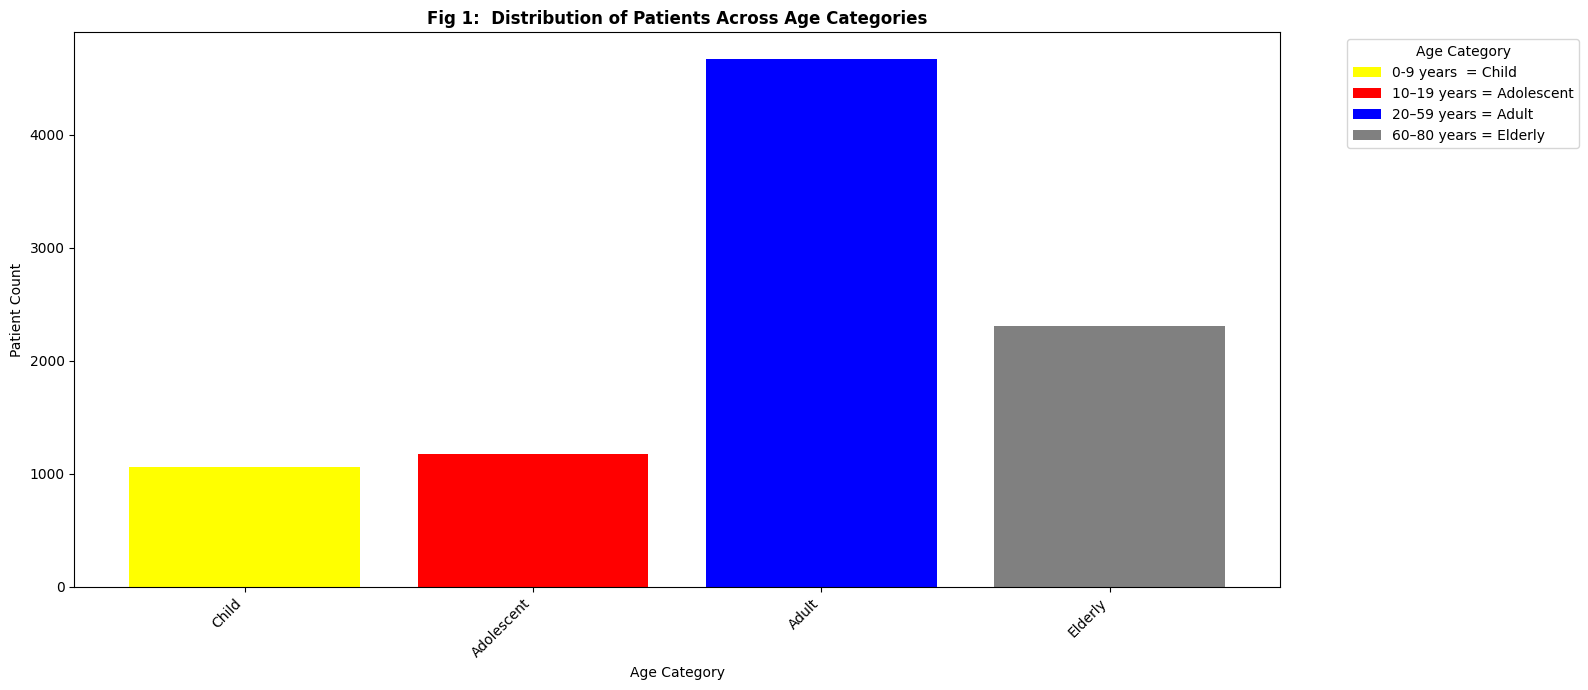

In [40]:
# AGE CATEGORY DISTRIBUTION ANALYSIS

age_cat_counts = df["Age Category"].value_counts().sort_index()

colors = (
    df.drop_duplicates("Age Category")
      .set_index("Age Category")["Age Color"]
      .reindex(age_cat_counts.index)
)

fig, ax = plt.subplots(figsize=(13,7))


bars = ax.bar(
    age_cat_counts.index,
    age_cat_counts.values,
    color=colors
)

plt.title("Fig 1:  Distribution of Patients Across Age Categories", weight="bold")
plt.xlabel("Age Category")
plt.ylabel("Patient Count")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Create legend 
legend_labels = [
    "0-9 years  = Child",
    "10–19 years = Adolescent",
    "20–59 years = Adult",
    "60–80 years = Elderly",
]

ax.legend(bars, legend_labels, title="Age Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

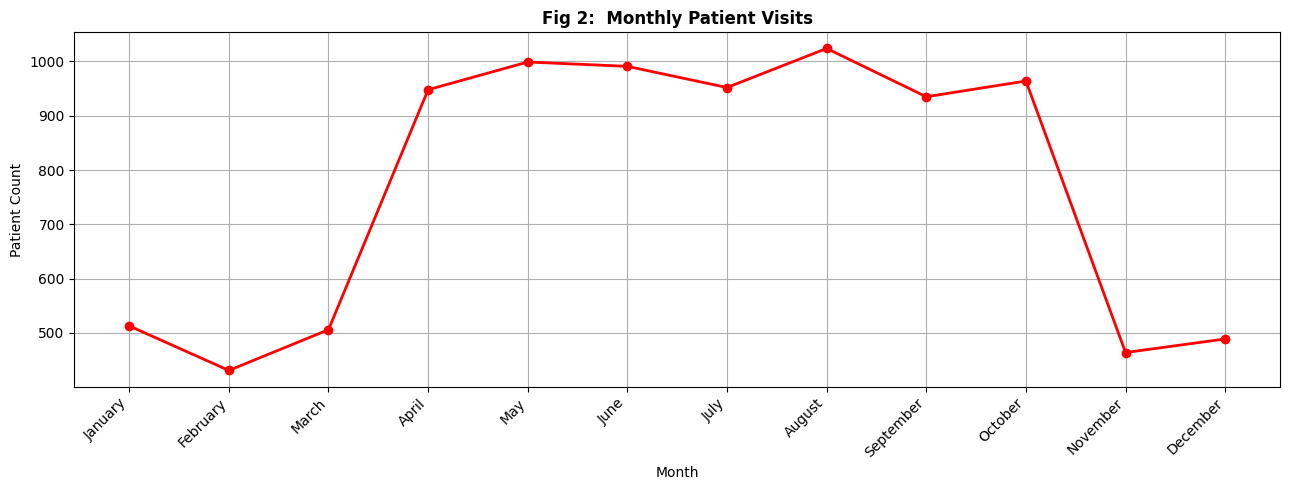

In [41]:
# MONTHLY PATIENT VISITS ANALYSIS

month_visits = df["Admission Month"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13,5))

ax.plot(
    month_visits.index,
    month_visits.values,
    marker='o',
    linewidth=2,
    color="red"
)

plt.title("Fig 2:  Monthly Patient Visits", weight="bold")
plt.xlabel("Month")
plt.ylabel("Patient Count")

plt.grid(True)

plt.xticks(rotation=45, ha="right")

plt.tight_layout();


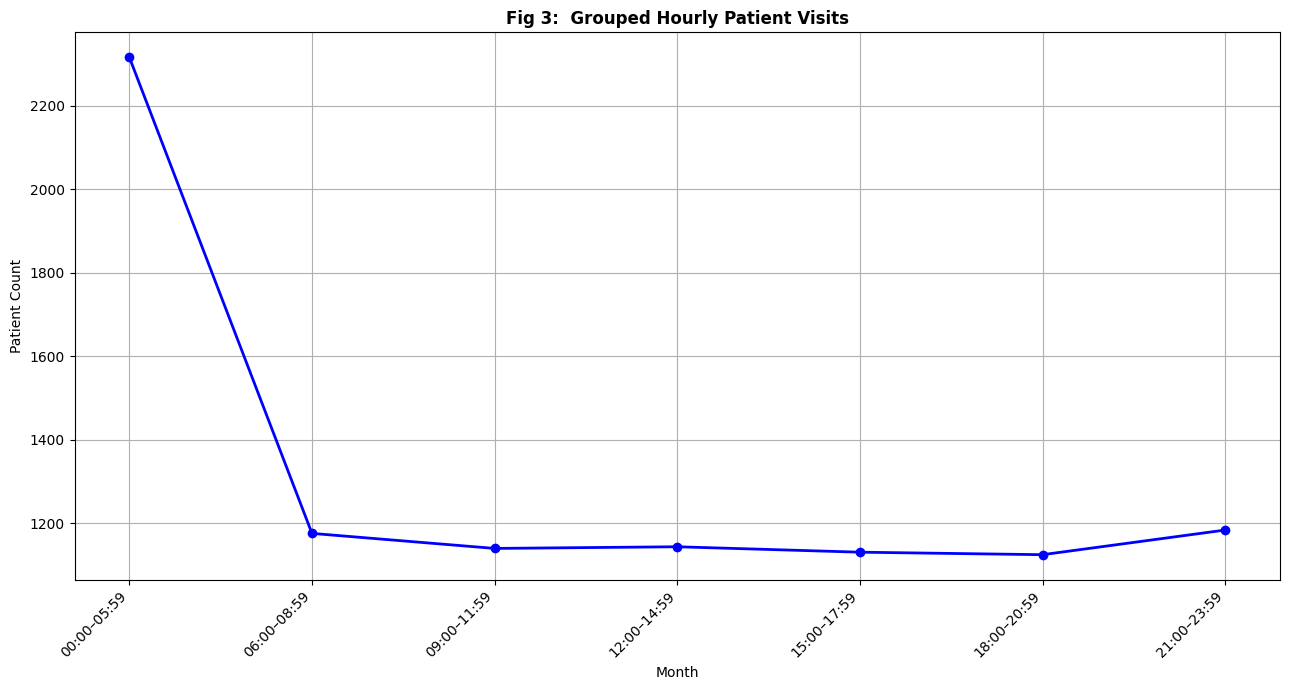

In [42]:
# GROUPED HOURLY PATIENT VISITS ANALYSIS

hourly_visits = df["Time Group"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13,7))

ax.plot(
    hourly_visits.index,
    hourly_visits.values,
    marker='o',
    linewidth=2,
    color="blue"
)

plt.title("Fig 3:  Grouped Hourly Patient Visits", weight="bold")
plt.xlabel("Month")
plt.ylabel("Patient Count")

plt.grid(True)

plt.xticks(rotation=45, ha="right")

plt.tight_layout();


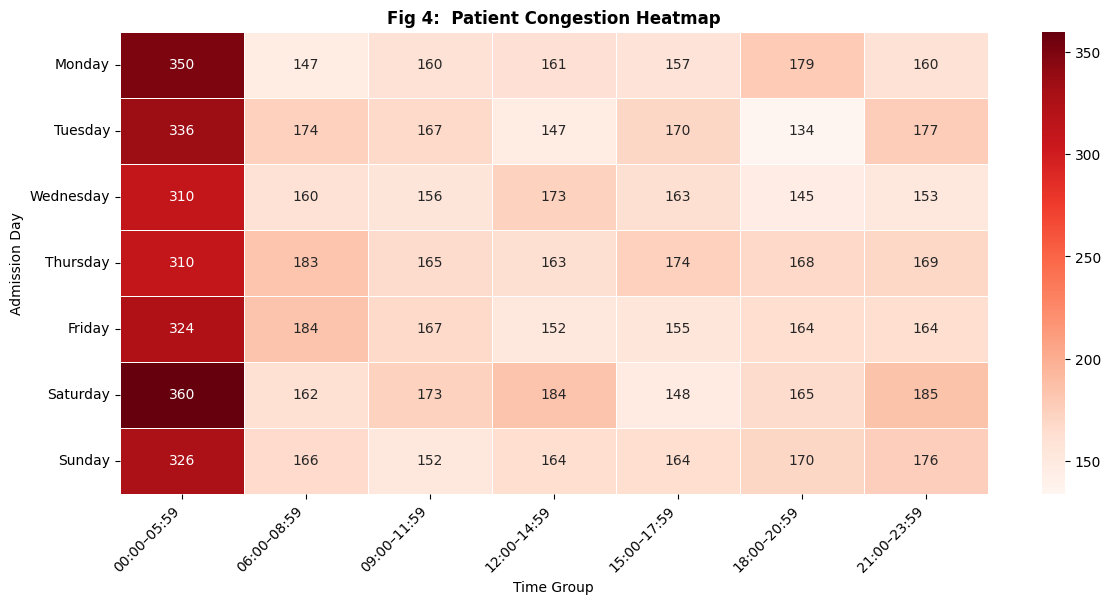

In [43]:
# PATIENT CONGESTION ANALYSIS

heatmap_data = df.pivot_table(
    index="Admission Day",
    columns="Time Group",
    values="Patient Age",
    aggfunc="count",
    observed=False
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5
)

plt.title("Fig 4:  Patient Congestion Heatmap", weight="bold")
plt.xlabel("Time Group")
plt.ylabel("Admission Day")

plt.xticks(rotation=45, ha="right")

plt.show()

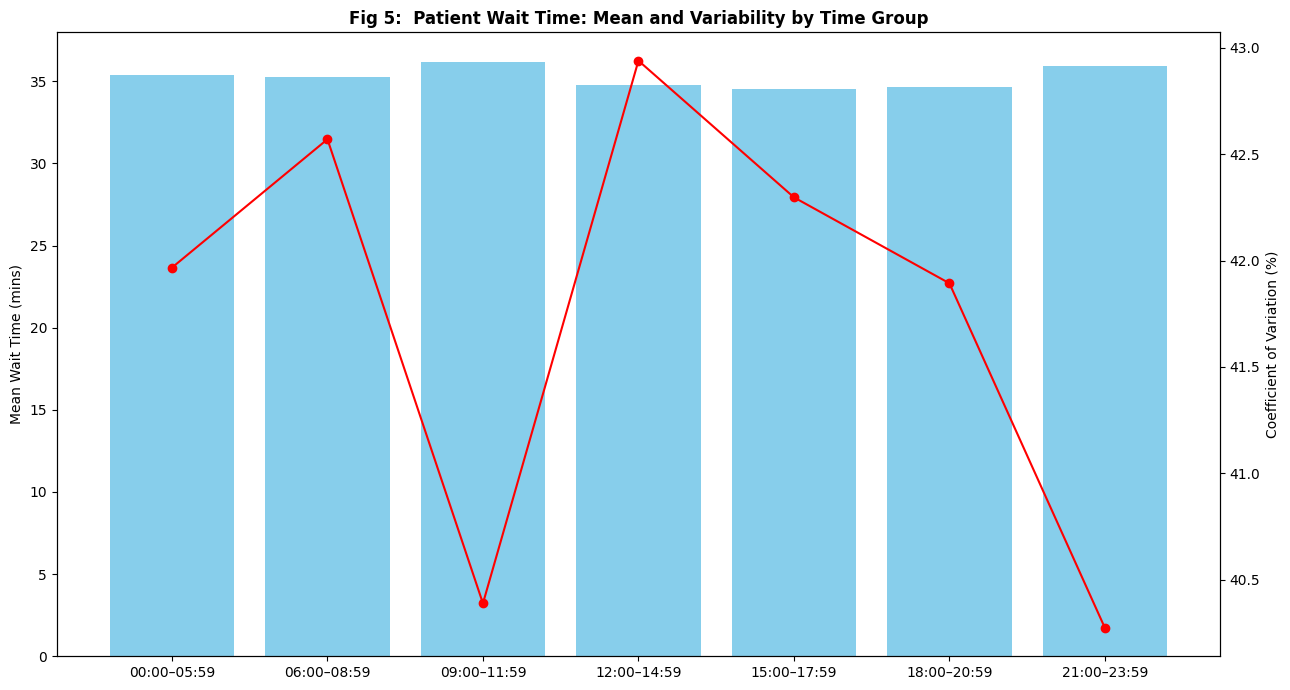

In [45]:
# PATIENT WAIT TIME VARIABILITY ANALYSIS

summary = df.groupby("Time Group", observed=False)["Patient Waittime"].agg(
    Mean_Wait="mean",
    CV=coefficient_of_variation
)

fig, ax1 = plt.subplots(figsize=(13,7))

# Bar plot for mean wait
ax1.bar(
    summary.index,
    summary["Mean_Wait"],
    color="skyblue"
)

ax1.set_ylabel("Mean Wait Time (mins)")

# Second axis for CV
ax2 = ax1.twinx()

ax2.plot(
    summary.index,
    summary["CV"],
    marker="o",
    color="red",
    )

ax2.set_ylabel("Coefficient of Variation (%)")

plt.title("Fig 5:  Patient Wait Time: Mean and Variability by Time Group", weight="bold")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
'''
1.Patient Admission Prediction:
GOAL: Develop a predictive model to forecast patient admissions based on historical data,
enabling better resource allocation and staffing decisions.
a: Check for Admission Distribution
'''
df["Patient Admission Flag"].value_counts()

Patient Admission Flag
Admission        4612
Not Admission    4604
Name: count, dtype: int64

In [12]:
df = df.reset_index(drop=True)

In [13]:
# Age Group vs Admission Flag

pd.crosstab(
    df["Age Group"],
    df["Patient Admission Flag"],
    normalize="index",
) * 100

Patient Admission Flag,Admission,Not Admission
Age Group,,
Under Five,51.724138,48.275862
School Age Child,48.310811,51.689189
Early Adolescent,53.710247,46.289753
Late Adolescent,50.244698,49.755302
Young Adult,49.494949,50.505051
Early Adult,50.750000,49.250000
Midlife Adult,48.810573,51.189427
Late Adult,50.390964,49.609036
Young Elderly,49.653380,50.346620


In [14]:
# Average Wait Time by Admission Flag

df.groupby("Patient Admission Flag")["Patient Waittime"].mean()

Patient Admission Flag
Admission        34.967910
Not Admission    35.552346
Name: Patient Waittime, dtype: float64

In [15]:
# Gender vs Admission Flag

pd.crosstab(
    df["Patient Gender"],
    df["Patient Admission Flag"],
    normalize=True
    ) * 100

Patient Admission Flag,Admission,Not Admission
Patient Gender,,
Female,24.294705,24.207899
Femaleemale,0.119358,0.065104
Male,25.629340,25.683594


In [16]:
# Time Group vs Admission Flag

pd.crosstab(
    df["Time Group"],
    df["Patient Admission Flag"],
    normalize="index",
) * 100

Patient Admission Flag,Admission,Not Admission
Time Group,,
00:00–05:59,49.136442,50.863558
06:00–08:59,49.404762,50.595238
09:00–11:59,49.736842,50.263158
12:00–14:59,52.185315,47.814685
15:00–17:59,49.867374,50.132626
18:00–20:59,50.755556,49.244444
21:00–23:59,50.168919,49.831081


In [17]:
# Month vs Admission Flag

pd.crosstab(
    df["Admission Month"],
    df["Patient Admission Flag"],
    normalize="index",
) * 100

Patient Admission Flag,Admission,Not Admission
Admission Month,,
January,52.436647,47.563353
February,51.972158,48.027842
March,50.000000,50.000000
April,47.890295,52.109705
May,49.549550,50.450450
June,49.142281,50.857719
July,52.731092,47.268908
August,46.484375,53.515625
September,51.871658,48.128342


In [18]:
# Target Encoding

df["Patient Admission Flag"] = df["Patient Admission Flag"].map({"Not Admission": 0, "Admission": 1})

In [19]:
# Define target

y = df["Patient Admission Flag"]

In [20]:
# Define features

X = df.drop(columns=["Patient Admission Flag"])

In [21]:
# Feature Encoding

X = pd.get_dummies(X, drop_first=True)

In [22]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [23]:
# Build Model

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
# Make Predictions

y_pred = model.predict(X_test)

In [25]:
# Evaluate Model

accuracy_score(y_test, y_pred)

0.5054229934924078

In [26]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[468, 456],
       [456, 464]])

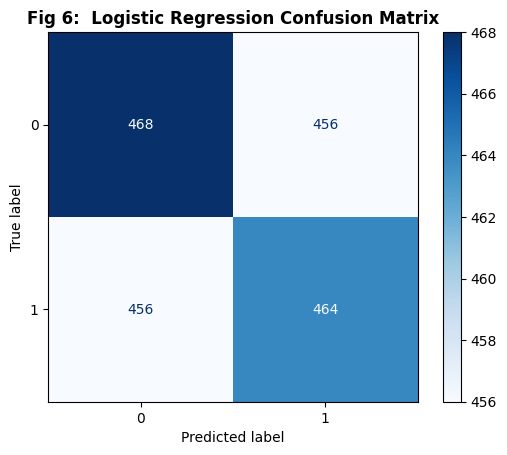

In [46]:
# Visual Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Fig 6:  Logistic Regression Confusion Matrix", weight="bold")
plt.show()


In [28]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.51      0.51       924
           1       0.50      0.50      0.50       920

    accuracy                           0.51      1844
   macro avg       0.51      0.51      0.51      1844
weighted avg       0.51      0.51      0.51      1844



In [29]:
"""Due to initial logistic regression model's limited predictive capacity,
I am implementing a Random Forest Classifier as it performs better with nonlinear patterns."""

"Due to initial logistic regression model's limited predictive capacity,\nI am implementing a Random Forest Classifier as it performs better with nonlinear patterns."

In [30]:
# Build Random Forest Model

rfc_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
    )

# Train the model

rfc_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
# predict with Random Forest Model
rfc_y_pred = rfc_model.predict(X_test)

# Classification Report for Random Forest Model

print(classification_report(y_test, rfc_y_pred))


              precision    recall  f1-score   support

           0       0.53      0.56      0.55       924
           1       0.53      0.50      0.52       920

    accuracy                           0.53      1844
   macro avg       0.53      0.53      0.53      1844
weighted avg       0.53      0.53      0.53      1844



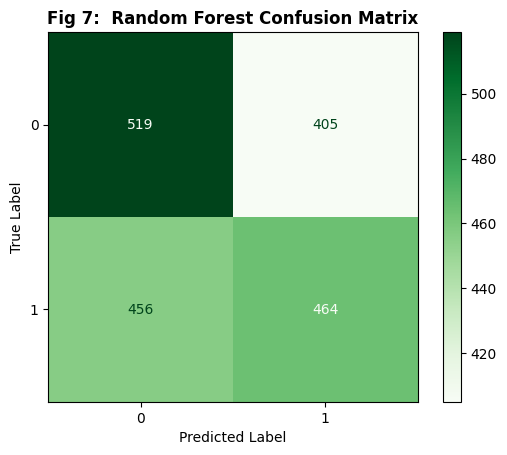

In [47]:
# Confusion Matrix Display for Random Forest Model

ConfusionMatrixDisplay.from_estimator(rfc_model, X_test, y_test, cmap="Greens")

# Add title
plt.title("Fig 7:  Random Forest Confusion Matrix", weight="bold")

# Add axis labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [33]:
# Feature Importance

importance = rfc_model.feature_importances_

feat_imp = pd.Series(
    importance,
    index=X_train.columns
).sort_values(ascending=True)

feat_imp.tail(19)

Admission Month_October           0.017927
Admission Day_Wednesday           0.019559
Time Group_12:00–14:59            0.019610
Patient Race_Asian                0.019693
Time Group_21:00–23:59            0.019955
Admission Day_Thursday            0.020057
Admission Day_Sunday              0.020262
Time Group_18:00–20:59            0.020339
Time Group_06:00–08:59            0.020598
Time Group_09:00–11:59            0.020881
Time Group_15:00–17:59            0.020979
Admission Day_Tuesday             0.021221
Admission Day_Saturday            0.021233
Admission Day_Friday              0.021323
Patient Race_Two or More Races    0.022531
Patient Race_White                0.028634
Patient Gender_Male               0.040492
Patient Age                       0.158629
Patient Waittime                  0.190207
dtype: float64